# Muni-CEF tax-loss season — a quantitative teardown 🔬
### Per-winter basket one-sample *t*'s · an exact 132-pair seasonal placebo · a 26-winter VWLTX extension · midpoint fade split · costs × 4 legs on the January swap · the Dec-15 vs Jan-15 paired race · a planted-knob synthetic control

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Buy Dec-15, not Jan-15?: Mixed](https://img.shields.io/badge/Buy_Dec--15%2C_not_Jan--15%3F-Mixed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim (Starks, Yong & Zheng 2006, JF) is the cleanest identification in the tax-loss-selling literature — muni CEF holders are ~100% taxable retail — so the job here is an honest replication on the modern tape: a per-winter unit that kills cross-fund pseudo-replication, an exhaustive month-pair placebo, and real costs on the actionable trade.

> ⚠️ **Data + survivorship note.** Fixed **12-fund** seasoned muni-CEF panel, all still trading in 2026 — a *survivor* panel (merged/liquidated funds absent; for a seasonal test the tilt is milder than for a level edge, but a surviving panel is a healthier, more-owned panel — exactly the clientele the story needs). Real data: yfinance total-return closes, 2000→2026; discount motion proxied by fund-minus-benchmark excess (benchmarks price at NAV). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprint `5f10f3e3801d`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from muni_cef_tax_loss import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX = data.load_real()
    EX = data.monthly_excess(PX, bench=data.BENCH)        # MUB-excess panel (2007-10 ->)
    EX2 = data.monthly_excess(PX, bench=data.ALT_BENCH)   # VWLTX-excess panel (2000 ->)
    WT = st.winter_table(EX)
    WT2 = st.winter_table(EX2)
else:
    PX = EX = EX2 = WT = WT2 = None
print("real muni-CEF cache present:", HAVE_REAL,
      "| MUB-excess months:", (0 if EX is None else len(EX)),
      "| winters:", (0 if WT is None else len(WT)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2000-01-03', 'end': '2026-06-30', 'rows': 6662, 'fingerprint': '5f10f3e3801d', 'n_funds': 12, 'months': 225, 'panel_start': '2007-10', 'n_winters': 19, 'n_winters_alt': 26, 'pooled': {'dec': -13.05, 'n_dec': 228, 'w_dec': -0.88, 'jan': 186.27, 'n_jan': 228, 'w_jan': 6.57, 'rest': 3.52, 'n_rest': 2244, 'w_jan_dec': 6.1}, 'dec_bps': -15.75, 't_dec': -0.33, 'jan_bps': 191.25, 't_jan': 2.27, 'hit_jan': 84.2, 'snap_bps': 207.0, 't_snap': 1.83, 'hit_snap': 73.7, 'snap_ac1': 0.069, 'placebo_rank': 4, 'placebo_p': 0.0303, 'placebo_floor': 0.0076, 'alt': {'jan': 180.34, 't_jan': 3.51, 'hit': 88.5, 'dec': 16.31, 't_dec': 0.49, 'snap': 164.03, 't_snap': 2.73, 'p': 0.0455, 'rank': 6}, 'fade': [('MUB 2007-2016', 326.63, 2.56, 10), ('MUB 2017-2025', 40.83, 0.45, 9), ('VWLTX 2000-2012', 274.92, 3.72, 13), ('VWLTX 2013-2025', 85.76, 1.34, 13)], 'fade_welch': 1.83, 'swap': [(5.0, 20, 171.25, 2.03, 84.2), (10.0, 40, 151.25, 1.79, 78.9), (25.0, 100, 91.25, 1.08, 73.7)], 'swap_gross': 191.25, 'dec15': 267.92, 'jan15': 33.46, 'diff': 234.45, 't_diff': 1.78, 'hit_diff': 73.7, 'ex08': 114.21, 't_ex08': 2.02, 'n_ex08': 18, 'syn': [(0, 0, 24.8, 0.65, 22.2, 0.53, 0.2424), (100, 100, 124.8, 3.26, 222.2, 5.33, 0.0076)]}


real muni-CEF cache present: True | MUB-excess months: 225 | winters: 19


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `MIXED` | *Real on the January snap-back, None on the December-month dump.* January excess **+191.25 bps** at one-sample **t = 2.27** (19 winters, hit 84%); **+180.34 bps at t = 3.51** on 26 VWLTX winters; exact placebo p = 0.030/0.045. December: -15.75 bps, t = -0.33. Survivorship + a named fade. |
| **Tradability** | `FRAGILE` | January swap nets **+171.25 bps/winter at t = 2.03** at 5 bps one-way; **t = 1.79** at 10 bps; post-2016 gross (+41 bps) sits below the 40–100 bps drag. Once a year, on thin funds. |
| **Buy Dec-15, not Jan-15?** | `MIXED` | Paired difference **+234.45 bps** (hit 74%), but **t = 1.78** full-sample and **+114.21 bps at t = 2.02** ex-2008 — directionally decisive, not sealed. |

> 💡 In plain words: January is genuinely special for these funds — on both benchmarks — but the December calendar month never shows the dump (it hides inside the month), and the tradable once-a-year version is thin and fading.

## 1 · The claim, steelmanned

Let $r^f_{m}$ be fund $f$'s monthly total return and $r^B_m$ the NAV-priced benchmark's (MUB; VWLTX pre-2007). The **discount-motion proxy** is the excess

$$e^f_m = r^f_m - r^B_m,$$

negative when the fund's *price* lags the muni market (discount widening). Equal-weight the panel into a basket $\bar e_m$, and for each winter $y$ take the pair $(\bar e_{\mathrm{Dec},y},\ \bar e_{\mathrm{Jan},y+1})$ — **one observation per winter**.

- **H₁ (the dump).** $\mathbb{E}[\bar e_{\mathrm{Dec}}] < 0$.
- **H₂ (the snap-back).** $\mathbb{E}[\bar e_{\mathrm{Jan}}] > 0$, and the Dec→Jan contrast is extreme among all month pairs.
- **H₃ (actionable).** A Dec-15 entry beats a Jan-15 entry to a common end-Feb exit, net of 4 one-way legs.

We find **H₂ supported** (t = 2.27 on MUB, 3.51 on VWLTX), **H₁ rejected at monthly grain** (t = -0.33; the dump lives *inside* December), **H₃ directionally supported but uncertified** (t = 1.78).

## 2 · So what? — the honesty traps this study must dodge

**(a) Pseudo-replication.** All muni CEFs load on one discount factor; a given January is essentially **one** draw, not twelve. Pooled fund-month Welch *t*'s (January vs rest = +6.57 on n = 228) flatter the effect — we quote them as *secondary* and run the primary test on the per-winter basket:

$$t = \frac{\overline{x}}{s_x/\sqrt{N}},\qquad N = 19\ \text{(MUB)},\ 26\ \text{(VWLTX)} \text{ non-overlapping winters}.$$

**(b) Calendar snooping.** Dec→Jan is 1 of 132 ordered month pairs; a placebo must price that in. Ours is **exact** — a full enumeration, no RNG, floor p = 1/132 = 0.0076.

**(c) Post-publication decay.** Published 2006 (McLean-Pontiff territory): we split each tape at its midpoint — not snooped — and test the *difference* with a Welch *t*.

**(d) Costs on the real trade.** The swap fires 4 one-way legs a winter on funds whose half-spreads alone can reach 10 bps.

## 3 · How we'd know — the protocol

- **Universe.** 12 seasoned national muni CEFs across five sponsors; benchmarks MUB (2007-09 →) and VWLTX (2000 →). Daily total-return closes, 2000-01-03 → 2026-06-30 (6,662 rows). **Survivor** panel — named.
- **Proxy.** Monthly fund-minus-benchmark excess; both legs total-return.
- **Timing.** The signal is a **fixed calendar rule**; every entry/exit fills at the first close *after* its decision point — the single execution lag.
- **Primary.** Per-winter basket one-sample *t* (19 MUB winters; snap lag-1 autocorrelation +0.069 → plain *t* appropriate on annual data).
- **Placebo.** Exact rank of the Dec→Jan contrast among all 132 ordered month pairs.
- **Costs.** 4 one-way legs × 5/10/25 bps × NAV per winter, charged against the January excess.
- **Third axis.** Paired Dec-15 vs Jan-15 entries, common last-Feb-close exit.
- **Positive control.** Synthetic excess panel (common factor + fund noise) with plantable December-dump / January-snap knobs; (0, 0) must not fire.

## 4 · The teardown

### 4a · The per-winter basket — the primary test

One December and one January per winter, equal-weight basket, MUB excess.

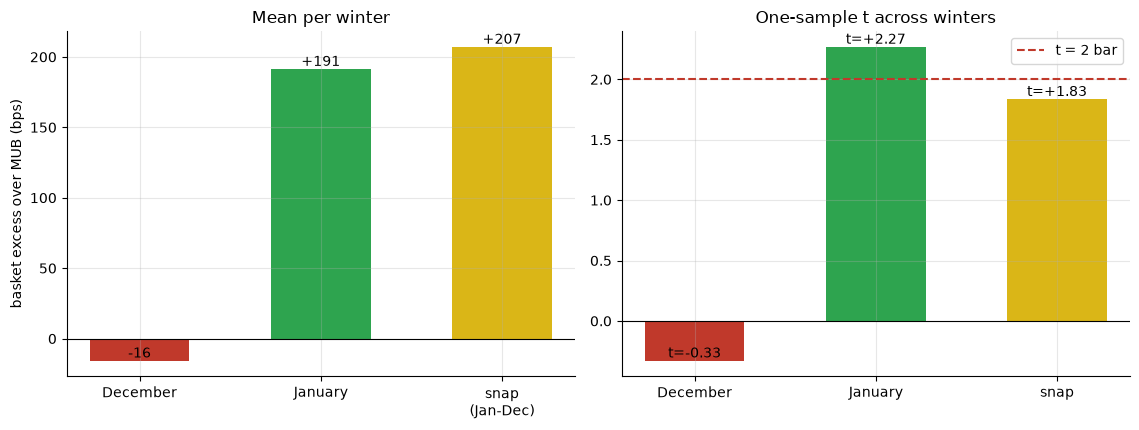

Dec -15.75 bps (t=-0.33)   Jan +191.25 bps (t=+2.27)   snap +207.00 bps (t=+1.83)


In [2]:
if HAVE_REAL:
    ws = st.winter_stats(WT)
    dec, jan, snap = ws['dec_mean_bps'], ws['jan_mean_bps'], ws['snap_mean_bps']
    td, tj, tsn = ws['t_dec'], ws['t_jan'], ws['t_snap']
else:
    dec, jan, snap = R['dec_bps'], R['jan_bps'], R['snap_bps']
    td, tj, tsn = R['t_dec'], R['t_jan'], R['t_snap']
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
axes[0].bar(['December', 'January', 'snap\n(Jan-Dec)'], [dec, jan, snap],
            color=[RED, GREEN, AMBER], width=.55)
for i, v in enumerate([dec, jan, snap]):
    axes[0].annotate(f'{v:+.0f}', (i, v), ha='center', va='bottom')
axes[0].axhline(0, c='k', lw=.8); axes[0].set_ylabel('basket excess over MUB (bps)')
axes[0].set_title('Mean per winter')
axes[1].bar(['December', 'January', 'snap'], [td, tj, tsn], color=[RED, GREEN, AMBER], width=.55)
axes[1].axhline(2, ls='--', c=RED, label='t = 2 bar'); axes[1].axhline(0, c='k', lw=.8)
for i, v in enumerate([td, tj, tsn]):
    axes[1].annotate(f't={v:+.2f}', (i, v), ha='center', va='bottom')
axes[1].set_title('One-sample t across winters'); axes[1].legend()
plt.tight_layout(); plt.show()
print(f'Dec {dec:+.2f} bps (t={td:+.2f})   Jan {jan:+.2f} bps (t={tj:+.2f})   snap {snap:+.2f} bps (t={tsn:+.2f})')

> 💡 In plain words: January clears the bar (**+191 bps, t = 2.27**, hit 84%); December is statistically nothing (-16 bps, t = -0.33). The claim's *snap-back* half is real; its *dump-month* half is not visible at monthly grain — §4e shows where the dump actually lives.

Secondary pooled fund-month view (pseudo-replication caveat): January vs rest Welch t = +6.57 (n = 228), December vs rest -0.88 (n = 228), January vs December +6.10 — same shape, flattered n.

### 4b · The exact seasonal placebo — Dec→Jan among all 132 ordered month pairs

Could a random pair of months look this special? Enumerate **every** ordered pair (a, b), statistic = seasonal mean(b) − mean(a) of the basket excess.

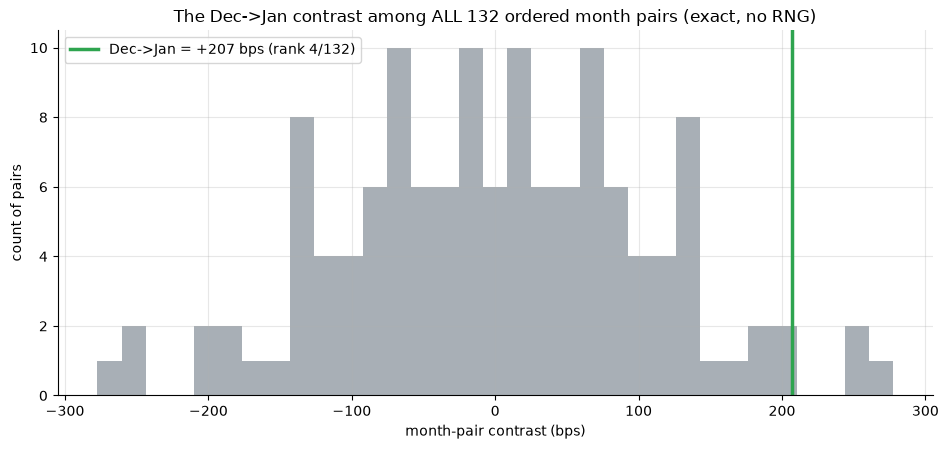

observed +207.00 bps   rank 4/132   exact p = 0.0303 (floor 0.0076)


In [3]:
if HAVE_REAL:
    pl = st.exact_pair_placebo(EX)
    vals = np.array(list(pl['pairs'].values())) * 1e4
    obs, p, rank = pl['obs'] * 1e4, pl['p_value'], pl['rank']
else:
    rng = np.random.default_rng(0); vals = rng.normal(0, 90, 132)
    obs, p, rank = R['snap_bps'], R['placebo_p'], R['placebo_rank']
fig, ax = plt.subplots(figsize=(9.6, 4.6))
ax.hist(vals, bins=33, color=GREY, alpha=.75)
ax.axvline(obs, c=GREEN, lw=2.5, label=f'Dec->Jan = {obs:+.0f} bps (rank {rank}/132)')
ax.set_xlabel('month-pair contrast (bps)'); ax.set_ylabel('count of pairs')
ax.set_title('The Dec->Jan contrast among ALL 132 ordered month pairs (exact, no RNG)')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed {obs:+.2f} bps   rank {rank}/132   exact p = {p:.4f} (floor {1/132:.4f})')

> 💡 In plain words: of all 132 ways to pick an ordered pair of months, Dec→Jan lands **4ᵗʰ** (exact p = 0.0303, floor 0.0076) — top 3%. And the pairs that beat it all involve January or February (January is the panel's best month, February its worst — the snap-back partly gives itself back). The seasonal structure has exactly the tax-loss calendar's shape.

### 4c · Robustness — the 26-winter VWLTX tape, and the fade

MUB only lists in 2007. VWLTX (Vanguard Long-Term Tax-Exempt, NAV-priced) extends the same test to 2000. Then the midpoint split on both benchmarks.

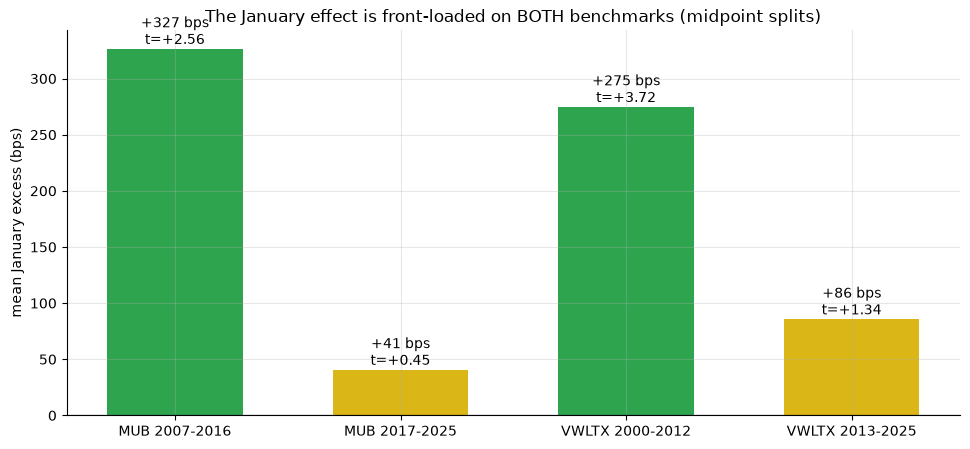

   MUB 2007-2016:  +326.63 bps  t = +2.56  (n=10)
   MUB 2017-2025:   +40.83 bps  t = +0.45  (n=9)
 VWLTX 2000-2012:  +274.92 bps  t = +3.72  (n=13)
 VWLTX 2013-2025:   +85.76 bps  t = +1.34  (n=13)


In [4]:
if HAVE_REAL:
    a = WT.loc[WT.index <= 2016, 'jan']; b = WT.loc[WT.index > 2016, 'jan']
    a2 = WT2.loc[WT2.index <= 2012, 'jan']; b2 = WT2.loc[WT2.index > 2012, 'jan']
    rows = [(x.mean() * 1e4, st.ttest_vs_zero(x), len(x)) for x in (a, b, a2, b2)]
else:
    rows = [(v, t, n) for _, v, t, n in R['fade']]
labels = [lbl for lbl, *_ in R['fade']]
means = [r[0] for r in rows]; ts = [r[1] for r in rows]
fig, ax = plt.subplots(figsize=(9.8, 4.6))
cols = [GREEN, AMBER, GREEN, AMBER]
ax.bar(labels, means, color=cols, width=.6)
for i, (m, t) in enumerate(zip(means, ts)):
    ax.annotate(f'{m:+.0f} bps\nt={t:+.2f}', (i, m), ha='center', va='bottom')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('mean January excess (bps)')
ax.set_title('The January effect is front-loaded on BOTH benchmarks (midpoint splits)')
plt.tight_layout(); plt.show()
for lbl, (m, t, n) in zip(labels, rows):
    print(f'{lbl:>16}: {m:+8.2f} bps  t = {t:+.2f}  (n={n})')

> 💡 In plain words: the full VWLTX tape *strengthens* the January leg (**+180.34 bps, t = 3.51**, hit 88%, placebo p = 0.0455) — but on **both** benchmarks the effect concentrates in the first half of the sample (MUB: +327 → +41 bps; VWLTX: +275 → +86 bps). The early-minus-late Welch t is **+1.83** — the fade is *not itself certified* at t ≥ 2, but the recent decade alone cannot certify the effect either. Classic McLean-Pontiff shape for a 2006-published anomaly; it drives the Tradability stamp.

### 4d · Costs — the January swap (hold MUB, swap into the basket for January)

Enter at the last December close, exit at the last January close; **4 one-way legs** per winter (sell MUB, buy basket, sell basket, buy MUB) at one-way cost × NAV. Gross P&L over just-holding-MUB is exactly the basket's January excess.

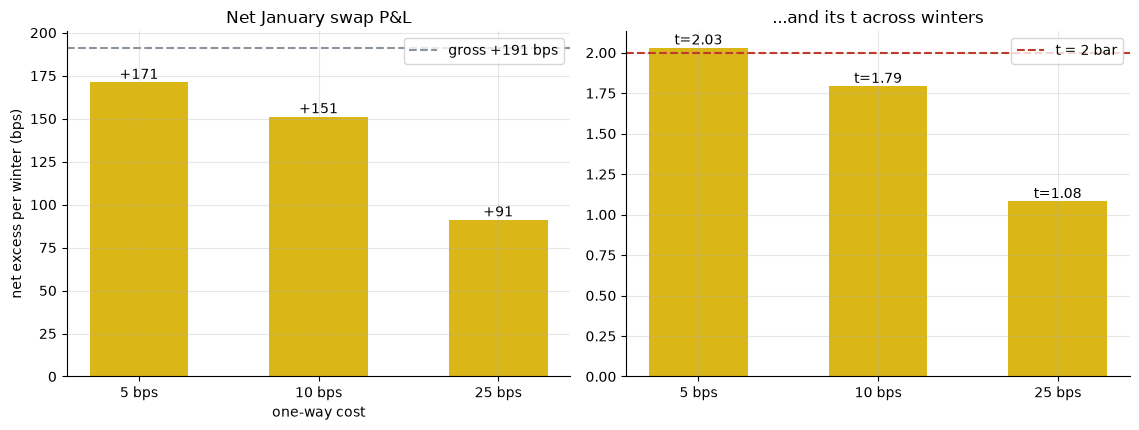

  5 bps one-way: net +171.25 bps/winter  t = +2.03
 10 bps one-way: net +151.25 bps/winter  t = +1.79
 25 bps one-way: net +91.25 bps/winter  t = +1.08


In [5]:
if HAVE_REAL:
    rows = [st.january_swap(WT, cost_bps=cb) for cb in (5.0, 10.0, 25.0)]
    nets = [r['net_mean_bps'] for r in rows]; ts = [r['t_net'] for r in rows]
    gross = rows[0]['gross_mean_bps']
else:
    nets = [s[2] for s in R['swap']]; ts = [s[3] for s in R['swap']]
    gross = R['swap_gross']
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
labels = ['5 bps', '10 bps', '25 bps']
axes[0].bar(labels, nets, color=AMBER, width=.55)
axes[0].axhline(gross, ls='--', c=GREY, label=f'gross {gross:+.0f} bps')
for i, v in enumerate(nets): axes[0].annotate(f'{v:+.0f}', (i, v), ha='center', va='bottom')
axes[0].set_ylabel('net excess per winter (bps)'); axes[0].set_xlabel('one-way cost')
axes[0].set_title('Net January swap P&L'); axes[0].legend()
axes[1].bar(labels, ts, color=AMBER, width=.55)
axes[1].axhline(2, ls='--', c=RED, label='t = 2 bar')
for i, v in enumerate(ts): axes[1].annotate(f't={v:.2f}', (i, v), ha='center', va='bottom')
axes[1].set_title('...and its t across winters'); axes[1].legend()
plt.tight_layout(); plt.show()
for lbl, n, t in zip(labels, nets, ts): print(f'{lbl:>7} one-way: net {n:+.2f} bps/winter  t = {t:+.2f}')

> 💡 In plain words: at 5 bps one-way the swap still clears the bar (**+171 bps net, t = 2.03**); at a realistic 10 bps for small CEFs it slips under (t = 1.79); at 25 bps it's t = 1.08. Worse: the post-2016 gross (+41 bps) sits *below* the 40–100 bps drag — the trade's last decade is net-negative. Capacity is a few $100k per fund before you *are* the January bid. **FRAGILE.**

### 4e · Third axis — Dec-15 vs Jan-15 (the actionable version)

Entry A = first close on/after Dec-15; entry B = first close on/after Jan-15; common exit = last February close. The paired per-winter difference is exactly the excess earned between Dec-15 and Jan-15 — where does the seasonal payoff actually live?

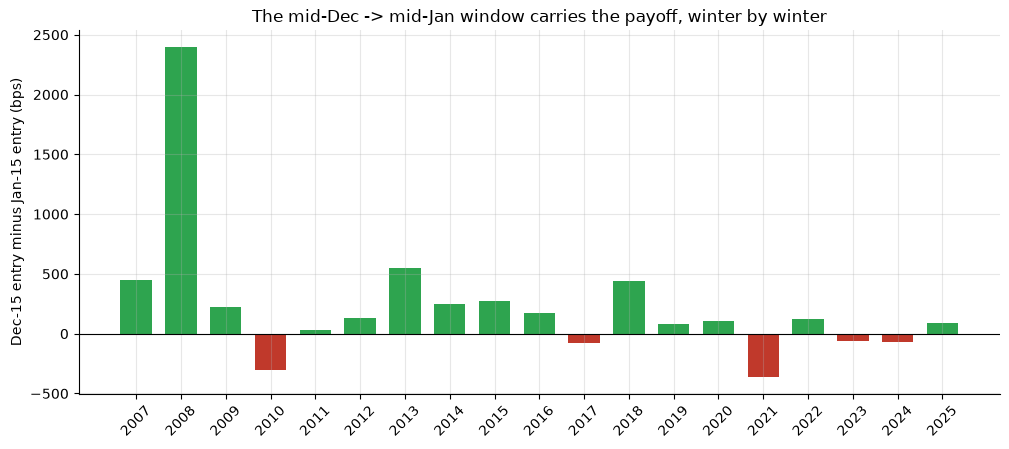

mean +234.5 bps   positive 14/19   ex-2008 mean +114.2 bps


In [6]:
if HAVE_REAL:
    dj = st.dec15_vs_jan15(PX, data.BENCH, data.FUNDS)
    yrs = [str(y) for y in dj.index]; diffs = (dj['diff'] * 1e4).values
else:
    yrs = [str(2007+i) for i in range(19)]; diffs = np.full(19, R['diff'])
fig, ax = plt.subplots(figsize=(10.2, 4.6))
ax.bar(yrs, diffs, color=[GREEN if v > 0 else RED for v in diffs], width=.7)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('Dec-15 entry minus Jan-15 entry (bps)')
ax.set_title('The mid-Dec -> mid-Jan window carries the payoff, winter by winter')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()
print(f'mean {diffs.mean():+.1f} bps   positive {(diffs>0).sum()}/{len(diffs)}   '
      f'ex-2008 mean {diffs[[y != "2008" for y in yrs]].mean():+.1f} bps')

> 💡 In plain words: buying **Dec-15** beats waiting for **Jan-15** by **+234 bps** on average (positive 74% of winters; the Jan-15 buyer keeps only +33 of +268 bps). This is where the "December dump" went: it happens mid-month and the recovery starts before year-end, so the calendar-month December nets to zero while the mid-Dec→mid-Jan window carries everything. But the *t* is 1.78 full-sample — the giant bar is the 2008 winter (+24% excess) — and ex-2008 it's +114 bps at t = 2.02 (n = 18): right at the bar. **MIXED** — directionally confirmed, not sealed.

### 4f · Synthetic control — the machinery is faithful

A deterministic monthly excess panel (common muni-CEF factor + fund noise) with plantable December-dump / January-snap knobs. Zero knobs must NOT fire; planted knobs must light up.

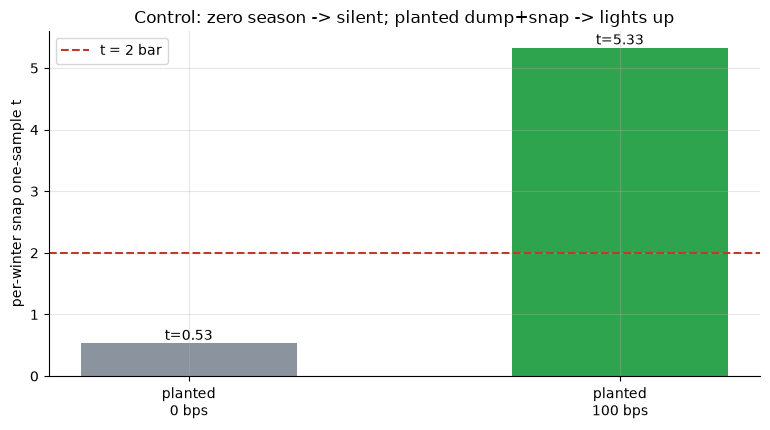

planted +0 bps: Jan +24.8 (t=+0.65)  snap +22.2 (t=+0.53)  placebo p=0.2424
planted +100 bps: Jan +124.8 (t=+3.26)  snap +222.2 (t=+5.33)  placebo p=0.0076


In [7]:
res = []
for dump, snap in ((0.0, 0.0), (0.010, 0.010)):
    exs = data.synthetic_excess(dump=dump, snap=snap, seed=616)
    wts = st.winter_table(exs)
    wss = st.winter_stats(wts)
    pls = st.exact_pair_placebo(exs)
    res.append((dump * 1e4, wss['jan_mean_bps'], wss['t_jan'], wss['snap_mean_bps'],
                wss['t_snap'], pls['p_value']))
fig, ax = plt.subplots(figsize=(7.8, 4.4))
labels = [f'planted\n{d:.0f} bps' for d, *_ in res]
tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t = 2 bar')
for i, t in enumerate(tvals): ax.annotate(f't={t:.2f}', (i, t), ha='center', va='bottom')
ax.set_ylabel('per-winter snap one-sample t')
ax.set_title('Control: zero season -> silent; planted dump+snap -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for d, j, tj, s, ts_, p in res:
    print(f'planted {d:+.0f} bps: Jan {j:+.1f} (t={tj:+.2f})  snap {s:+.1f} (t={ts_:+.2f})  placebo p={p:.4f}')

> 💡 In plain words: with nothing planted the machinery stays silent (snap t = 0.53, placebo p = 0.2424); with a 100-bps dump + 100-bps snap planted it fires hard (t = 5.33, placebo at its 1/132 floor). The measurement is unbiased — so the real-tape January *t*'s are genuine signal, not a construction artefact. *(A faithful-engine / power check only — never cited in support of the real-tape stamps.)*

## 5 · The verdict

- **Signal `MIXED`** (*Real on the January snap-back · None on the December-month dump*) — January excess **+191.25 bps at t = 2.27** (19 winters, hit 84%), **+180.34 bps at t = 3.51** on 26 VWLTX winters, exact placebo p = 0.030/0.045. December flat (-15.75 bps, t = -0.33). Survivorship named; fade named (post-2016 +41 bps, t = 0.45; fade Welch t = +1.83, not certified).
- **Tradability `FRAGILE`** — net **+171.25 bps/winter at t = 2.03** at 5 bps one-way, under the bar at 10 bps (t = 1.79); post-2016 gross below the cost drag; once-a-year, tiny thin funds. Not INVESTABLE.
- **Buy Dec-15, not Jan-15? `MIXED`** — **+234.45 bps** paired difference (hit 74%; Jan-15 keeps only +33 bps), but t = 1.78 full-sample and +114.21 bps at t = 2.02 ex-2008. Directionally confirmed, statistically not sealed.

## 6 · Going further

- **The proxy is the price of admission.** Without per-fund NAV the discount is proxied by fund-minus-benchmark excess; the CEFs' leverage adds noise (but no Dec/Jan calendar of its own). A CEFConnect-style NAV tape would sharpen every number here.
- **Condition on the loser.** Starks-Yong-Zheng's cross-sectional refinement — the snap-back concentrates in the funds with year-to-date *losses* to harvest — is the natural next study; our panel-level test averages over it.
- **The level cousin.** [367-closed-end-fund-discount](../../367-closed-end-fund-discount/README.md) (Real · Fragile) is the *level* edge on the same machinery; this was the *seasonal flow*. Both end at the same place: real mispricing, no capacity.

*The reproducible core is offline and deterministic; the primary unit is one winter, one observation, and the placebo is an exact enumeration. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*